In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("orvile/ultrasound-fetus-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ultrasound-fetus-dataset' dataset.
Path to dataset files: /kaggle/input/ultrasound-fetus-dataset


In [2]:
import os

os.listdir(path)

['ultrasound_fetus.csv', 'Ultrasound Fetus Dataset']

In [3]:
full_dataset_path=os.path.join(path,'Ultrasound Fetus Dataset','Ultrasound Fetus Dataset','Data','Data')
full_dataset_path

'/kaggle/input/ultrasound-fetus-dataset/Ultrasound Fetus Dataset/Ultrasound Fetus Dataset/Data/Data'

In [4]:
os.listdir(full_dataset_path)

['Datasets',
 'validation',
 'FetusDataset.csv',
 'Resnet_fineTuning.pth',
 'OverlayedImages',
 'test',
 'train']

In [5]:
train_path=os.path.join(full_dataset_path,'train')
test_path=os.path.join(full_dataset_path,'test')
val_path=os.path.join(full_dataset_path,'validation')

In [6]:
train_path

'/kaggle/input/ultrasound-fetus-dataset/Ultrasound Fetus Dataset/Ultrasound Fetus Dataset/Data/Data/train'

In [7]:
len(os.listdir(train_path))

3

In [8]:

def count_imgs(path):
  for folder in os.listdir(path): # 3 folders
    folder_path = os.path.join(path, folder) #path+1 folder in 1 iteration
    if os.path.isdir(folder_path):
        print(folder, len(os.listdir(folder_path)))
  print()

count_imgs(train_path)
count_imgs(test_path)
count_imgs(val_path)

benign 241
normal 242
malignant 1443

benign 51
normal 50
malignant 300

benign 43
normal 43
malignant 255



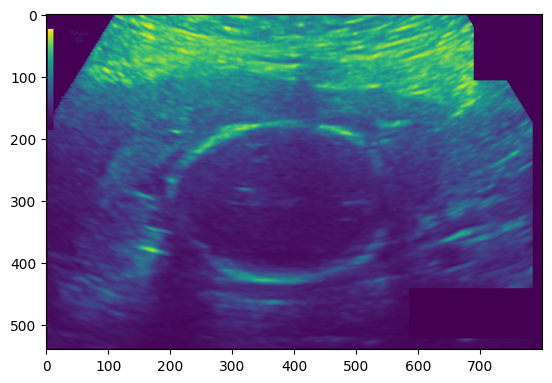

(540, 800)


In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

folder_img_path=os.path.join(train_path,'normal')
sample_img=os.listdir(folder_img_path)[0]
full_path=os.path.join(folder_img_path,sample_img)
img=Image.open(full_path)

plt.imshow(img)
plt.show()

print(np.array(img).shape)

In [10]:
print(img.mode) #L ->grayscale

L


In [11]:
#load the data
import tensorflow as tf

train_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    label_mode='categorical', #ohe
    color_mode='rgb',
    batch_size=32,
    shuffle=True,
    seed=42
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    val_path,
     image_size=(224,224),
    label_mode='categorical', #ohe
    color_mode='rgb',
    batch_size=32,
    shuffle=True
)

test_ds=tf.keras.utils.image_dataset_from_directory(
    test_path,
     image_size=(224,224),
    label_mode='categorical', #ohe
    color_mode='rgb',
    batch_size=32,
    shuffle=True
)

Found 1926 files belonging to 3 classes.
Found 341 files belonging to 3 classes.
Found 401 files belonging to 3 classes.


In [12]:
class_names=train_ds.class_names
class_names

['benign', 'malignant', 'normal']

as our dataset is imabalcned we will do asign classweights

In [13]:
counts=np.array([241,1443,242]) # number of images in the each class folders

#weigths=totalcounts/numclasses*images in the chat
weights=counts.sum()/(len(class_names)*counts)

class_weights={i:w for i,w in enumerate(weights)}

In [14]:
class_weights

{0: np.float64(2.663900414937759),
 1: np.float64(0.44490644490644493),
 2: np.float64(2.652892561983471)}

In [15]:
# create cnn model from scratch

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

cnn_model=Sequential([
    Conv2D(72,activation='relu',kernel_size=(3,3),padding='same',input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(62,activation='relu',kernel_size=(3,3),padding='same'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(3,activation='softmax')
])

cnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])


early=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


cnn_history=cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=1,
    class_weight=class_weights,
    callbacks=[early]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 24s 258ms/step - accuracy: 0.5135 - loss: 63.7783 - precision: 0.7018 - recall: 0.4361 - val_accuracy: 0.5073 - val_loss: 0.7781 - val_precision: 0.9574 - val_recall: 0.3959
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.4979 - loss: 0.8680 - precision: 0.9655 - recall: 0.3780 - val_accuracy: 0.4751 - val_loss: 0.7728 - val_precision: 0.9500 - val_recall: 0.3900
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.5171 - loss: 0.8361 - precision: 0.9385 - recall: 0.3884 - val_accuracy: 0.4927 - val_loss: 0.7939 - val_precision: 0.9007 - val_recall: 0.3988
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.5379 - loss: 0.7827 - precision: 0.9093 - recall: 0.4164 - val_accuracy: 0.5191 - val_loss: 0.8141 - val_precision: 0.7708 - val_recall: 0.4340
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.6584 - loss: 0.7536 - precision: 0.8479 - recall: 0.4891 - val_accuracy: 0.5513 - val_loss:

In [16]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16


# generators for VGG16 (no rescale)
train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_pre,
    width_shift_range=0.05, height_shift_range=0.05,
    fill_mode='constant', cval=0)
val_datagen  = ImageDataGenerator(preprocessing_function=vgg_pre)
test_datagen = ImageDataGenerator(preprocessing_function=vgg_pre)

train_ds = train_datagen.flow_from_directory(
    train_path, target_size=(224,224), color_mode='rgb',
    class_mode='categorical', batch_size=32, shuffle=True)

val_ds = val_datagen.flow_from_directory(
    val_path, target_size=(224,224), color_mode='rgb',
    class_mode='categorical', batch_size=32, shuffle=False)

test_ds = test_datagen.flow_from_directory(
    test_path, target_size=(224,224), color_mode='rgb',
    class_mode='categorical', batch_size=32, shuffle=False)

# sanity check: VGG range should be roughly -120 to +150, NOT 0 to 1
x, y = next(train_ds)
print(x.min(), x.max())

vgg_base1 = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_base1.trainable = False   # freeze first

vgg_model1 = Sequential([
    vgg_base1,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

vgg_model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early = EarlyStopping(
    monitor='val_loss',        # safer than val_recall
    patience=5,
    restore_best_weights=True
)

vgg_history1 = vgg_model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early]
)

Found 1926 images belonging to 3 classes.
Found 341 images belonging to 3 classes.
Found 401 images belonging to 3 classes.
-123.68 148.061
Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 69s 862ms/step - accuracy: 0.5119 - loss: 2.0645 - precision: 0.5226 - recall: 0.4933 - val_accuracy: 0.5572 - val_loss: 0.8231 - val_precision: 0.6597 - val_recall: 0.4604
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 38s 619ms/step - accuracy: 0.5234 - loss: 0.9763 - precision: 0.6720 - recall: 0.4361 - val_accuracy: 0.5337 - val_loss: 0.7555 - val_precision: 0.8831 - val_recall: 0.3988
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 650ms/step - accuracy: 0.5213 - loss: 0.9080 - precision: 0.8163 - recall: 0.3993 - val_accuracy: 0.4985 - val_loss: 0.8066 - val_precision: 0.8782 - val_recall: 0.4018
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 38s 615ms/step - accuracy: 0.5031 - loss: 0.9065 - precision: 0.8641 - recall: 0.3894 - val_accuracy: 0.5337 - val_loss: 0.7059 - val_precision: 0.9783 - val_recall: 0.3959
Epoch 5/30
61/61

In [17]:
vgg_base1.trainable = True
for layer in vgg_base1.layers[:-4]:      # only the last conv block trainable
    layer.trainable = False

vgg_model1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

vgg_history2 = vgg_model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early]
)

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 48s 688ms/step - accuracy: 0.5436 - loss: 0.8990 - precision: 0.8357 - recall: 0.4039 - val_accuracy: 0.5191 - val_loss: 0.7794 - val_precision: 0.9444 - val_recall: 0.3988
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 38s 620ms/step - accuracy: 0.5374 - loss: 0.8826 - precision: 0.8726 - recall: 0.3982 - val_accuracy: 0.5337 - val_loss: 0.7573 - val_precision: 0.9333 - val_recall: 0.4106
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 38s 630ms/step - accuracy: 0.5587 - loss: 0.8639 - precision: 0.9211 - recall: 0.4060 - val_accuracy: 0.5249 - val_loss: 0.7796 - val_precision: 0.9320 - val_recall: 0.4018
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 642ms/step - accuracy: 0.5701 - loss: 0.8511 - precision: 0.9029 - recall: 0.4154 - val_accuracy: 0.5660 - val_loss: 0.7212 - val_precision: 0.9459 - val_recall: 0.4106
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 633ms/step - accuracy: 0.5779 - loss: 0.8370 - precision: 0.8997 - recall: 0.4424 - val_accuracy: 0.5543 - val_los

In [18]:
train_ds

In [19]:
vgg_base1.trainable = True
for layer in vgg_base1.layers[:-8]:
    layer.trainable = False

vgg_model1.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                    loss='categorical_crossentropy', metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

vgg_history4 = vgg_model1.fit(train_ds, validation_data=val_ds, epochs=50,
                               class_weight=class_weights, callbacks=[early])

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 47s 692ms/step - accuracy: 0.5478 - loss: 0.8892 - precision: 0.8776 - recall: 0.4169 - val_accuracy: 0.5337 - val_loss: 0.7602 - val_precision: 0.9247 - val_recall: 0.3959
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 632ms/step - accuracy: 0.5348 - loss: 0.8764 - precision: 0.8850 - recall: 0.4034 - val_accuracy: 0.5396 - val_loss: 0.8057 - val_precision: 0.8726 - val_recall: 0.4018
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 669ms/step - accuracy: 0.5815 - loss: 0.8480 - precision: 0.8991 - recall: 0.4304 - val_accuracy: 0.5630 - val_loss: 0.7524 - val_precision: 0.8391 - val_recall: 0.4282
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 45s 743ms/step - accuracy: 0.5810 - loss: 0.8410 - precision: 0.8817 - recall: 0.4372 - val_accuracy: 0.5073 - val_loss: 0.7766 - val_precision: 0.9272 - val_recall: 0.4106
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 45s 730ms/step - accuracy: 0.5779 - loss: 0.8460 - precision: 0.9410 - recall: 0.4226 - val_accuracy: 0.5220 - val_los

In [20]:
from tensorflow.keras.applications import EfficientNetB0

eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
eff_base.trainable = False

eff_model = Sequential([
    eff_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])
eff_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# EfficientNet needs raw 0-255, so use fresh generators with NO preprocessing_function
train_datagen_eff = ImageDataGenerator(
    width_shift_range=0.05, height_shift_range=0.05, fill_mode='constant', cval=0)
val_datagen_eff = ImageDataGenerator()

train_ds_eff = train_datagen_eff.flow_from_directory(train_path, target_size=(224,224),
    color_mode='rgb', class_mode='categorical', batch_size=32, shuffle=True)
val_ds_eff = val_datagen_eff.flow_from_directory(val_path, target_size=(224,224),
    color_mode='rgb', class_mode='categorical', batch_size=32, shuffle=False)

eff_model.fit(train_ds_eff, validation_data=val_ds_eff, epochs=50,
              class_weight=class_weights, callbacks=[early])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1926 images belonging to 3 classes.
Found 341 images belonging to 3 classes.
Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.4901 - loss: 0.9723 - val_accuracy: 0.5073 - val_loss: 0.8109
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 636ms/step - accuracy: 0.4964 - loss: 0.9101 - val_accuracy: 0.5015 - val_loss: 0.7391
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 640ms/step - accuracy: 0.5078 - loss: 0.8888 - val_accuracy: 0.4956 - val_loss: 0.8003
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 636ms/step - accuracy: 0.4979 - loss: 0.8850 - val_accuracy: 0.5132 - val_loss: 0.8253
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 39s 637ms/step - accuracy: 0.5026 - loss: 0.8779 - val_accuracy: 0.5015 - val_loss: 0.7622


In [21]:
eff_base.trainable = True
for layer in eff_base.layers[:-20]:      # unfreeze last ~20 layers
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

eff_history = eff_model.fit(
    train_ds_eff, validation_data=val_ds_eff, epochs=50,
    class_weight=class_weights, callbacks=[early]
)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.4974 - loss: 1.0127 - precision: 0.5623 - recall: 0.4637 - val_accuracy: 0.4927 - val_loss: 0.7881 - val_precision: 0.9020 - val_recall: 0.4047
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 655ms/step - accuracy: 0.5047 - loss: 0.9482 - precision: 0.6229 - recall: 0.4512 - val_accuracy: 0.4868 - val_loss: 0.7956 - val_precision: 0.9139 - val_recall: 0.4047
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 659ms/step - accuracy: 0.4964 - loss: 0.9362 - precision: 0.6659 - recall: 0.4273 - val_accuracy: 0.4897 - val_loss: 0.8180 - val_precision: 0.8616 - val_recall: 0.4018
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 655ms/step - accuracy: 0.5026 - loss: 0.9179 - precision: 0.7000 - recall: 0.4252 - val_accuracy: 0.4927 - val_loss: 0.8313 - val_precision: 0.8662 - val_recall: 0.3988
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 40s 655ms/step - accuracy: 0.5073 - loss: 0.9070 - precision: 0.7192 - recall: 0.4216 - val_accuracy: 0.4897 - val_loss: